In [ ]:
!pip install tensorflow
!pip install stardist

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.8/69.8 kB 6.0 MB/s eta 0:00:00


In [2]:
from stardist.models import StarDist2D

# prints a list of available models
StarDist2D.from_pretrained()

# creates a pretrained model
model = StarDist2D.from_pretrained('2D_versatile_fluo')

There are 4 registered models for 'StarDist2D':

Name                  Alias(es)
────                  ─────────
'2D_versatile_fluo'   'Versatile (fluorescent nuclei)'
'2D_versatile_he'     'Versatile (H&E nuclei)'
'2D_paper_dsb2018'    'DSB 2018 (from StarDist 2D paper)'
'2D_demo'             None
Found model '2D_versatile_fluo' for 'StarDist2D'.
Loading network weights from 'weights_best.h5'.
Loading thresholds from 'thresholds.json'.
Using default values: prob_thresh=0.479071, nms_thresh=0.3.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


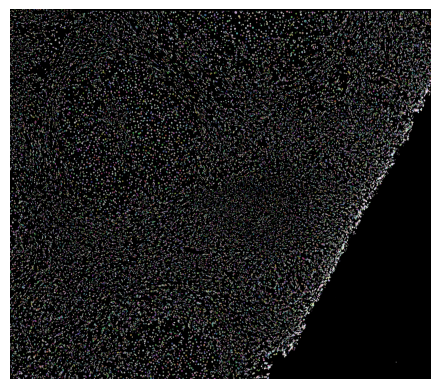

In [3]:
#from stardist.data import test_image_nuclei_2d
from stardist.plot import render_label
from csbdeep.utils import normalize
import matplotlib.pyplot as plt

#img = test_image_nuclei_2d()
img_path = '/content/drive/MyDrive/Master Thesis Multiplex/compare_stardist/220909_hu-p-002822_0dapi_backgroundSub_contrast_small.tif'
from PIL import Image
import numpy


img= Image.open(img_path)
np_img = numpy.array(img)

labels, _ = model.predict_instances(normalize(np_img))
plt.imshow(render_label(labels, img=np_img))
plt.axis("off")
plt.savefig('/content/220909_hu-p-002822_0dapi_backgroundSub_contrast_small_segmented.tif')
plt.imsave('/content/220909_hu-p-002822_0dapi_backgroundSub_contrast_small_segmented_overlay.png', labels, dpi = 300, cmap='gray')

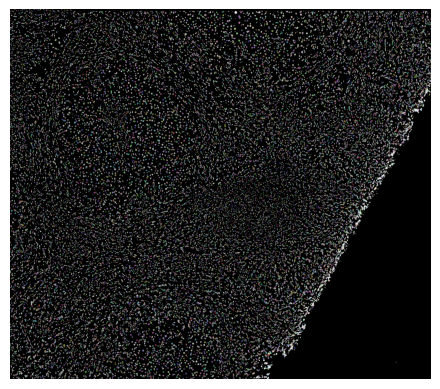

In [ ]:
#plt.rcParams["figure.figsize"] = [30.00, 30.00]
plt.imshow(render_label(labels, img=np_img))
plt.axis("off")
plt.savefig('/content/220909_hu-p-002822_0dapi_backgroundSub_contrast_small_segmented_inputoverlay.tif', dpi = 300)